# INM705 Skin Lesion Segmentation — Inference Notebook
This notebook loads the trained models for all four experimental conditions and runs inference on validation images from the ISIC 2018 dataset, displaying predicted segmentation masks alongside ground truth annotations.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'segmentation-models-pytorch', 'albumentations', '-q'])
print('Libraries ready!')

In [ ]:
import shutil, os

code_dir = '/content/drive/MyDrive/INM705/code'
for f in ['Dataset.py', 'Models.py']:
    shutil.copy(f'{code_dir}/{f}', f'/content/{f}')
    print(f'Copied {f}')

In [ ]:
import zipfile, os

drive_base = '/content/drive/MyDrive/INM705/ISIC2018'
extract_base = '/content/ISIC2018'
os.makedirs(extract_base, exist_ok=True)

zips = [
    'ISIC2018_Task1-2_Validation_Input.zip',
    'ISIC2018_Task1_Validation_GroundTruth.zip'
]

for z in zips:
    path = os.path.join(drive_base, z)
    print(f'Extracting {z}...')
    with zipfile.ZipFile(path, 'r') as zf:
        zf.extractall(extract_base)
    print('Done!')
print('Validation data ready!')

In [ ]:
import torch
from Models import build_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

checkpoint_dir = '/content/drive/MyDrive/INM705/checkpoints'
conditions = ['A', 'B', 'C', 'D']
models = {}

for cond in conditions:
    pth_path = f'{checkpoint_dir}/best_model_condition_{cond}.pth'
    m = build_model(cond)
    checkpoint = torch.load(pth_path, map_location=device)
    m.load_state_dict(checkpoint['model_state_dict'])
    m.eval().to(device)
    models[cond] = m
    print(f'Condition {cond} loaded - Best Val Dice: {checkpoint["val_dice"]:.4f} (epoch {checkpoint["epoch"]})')

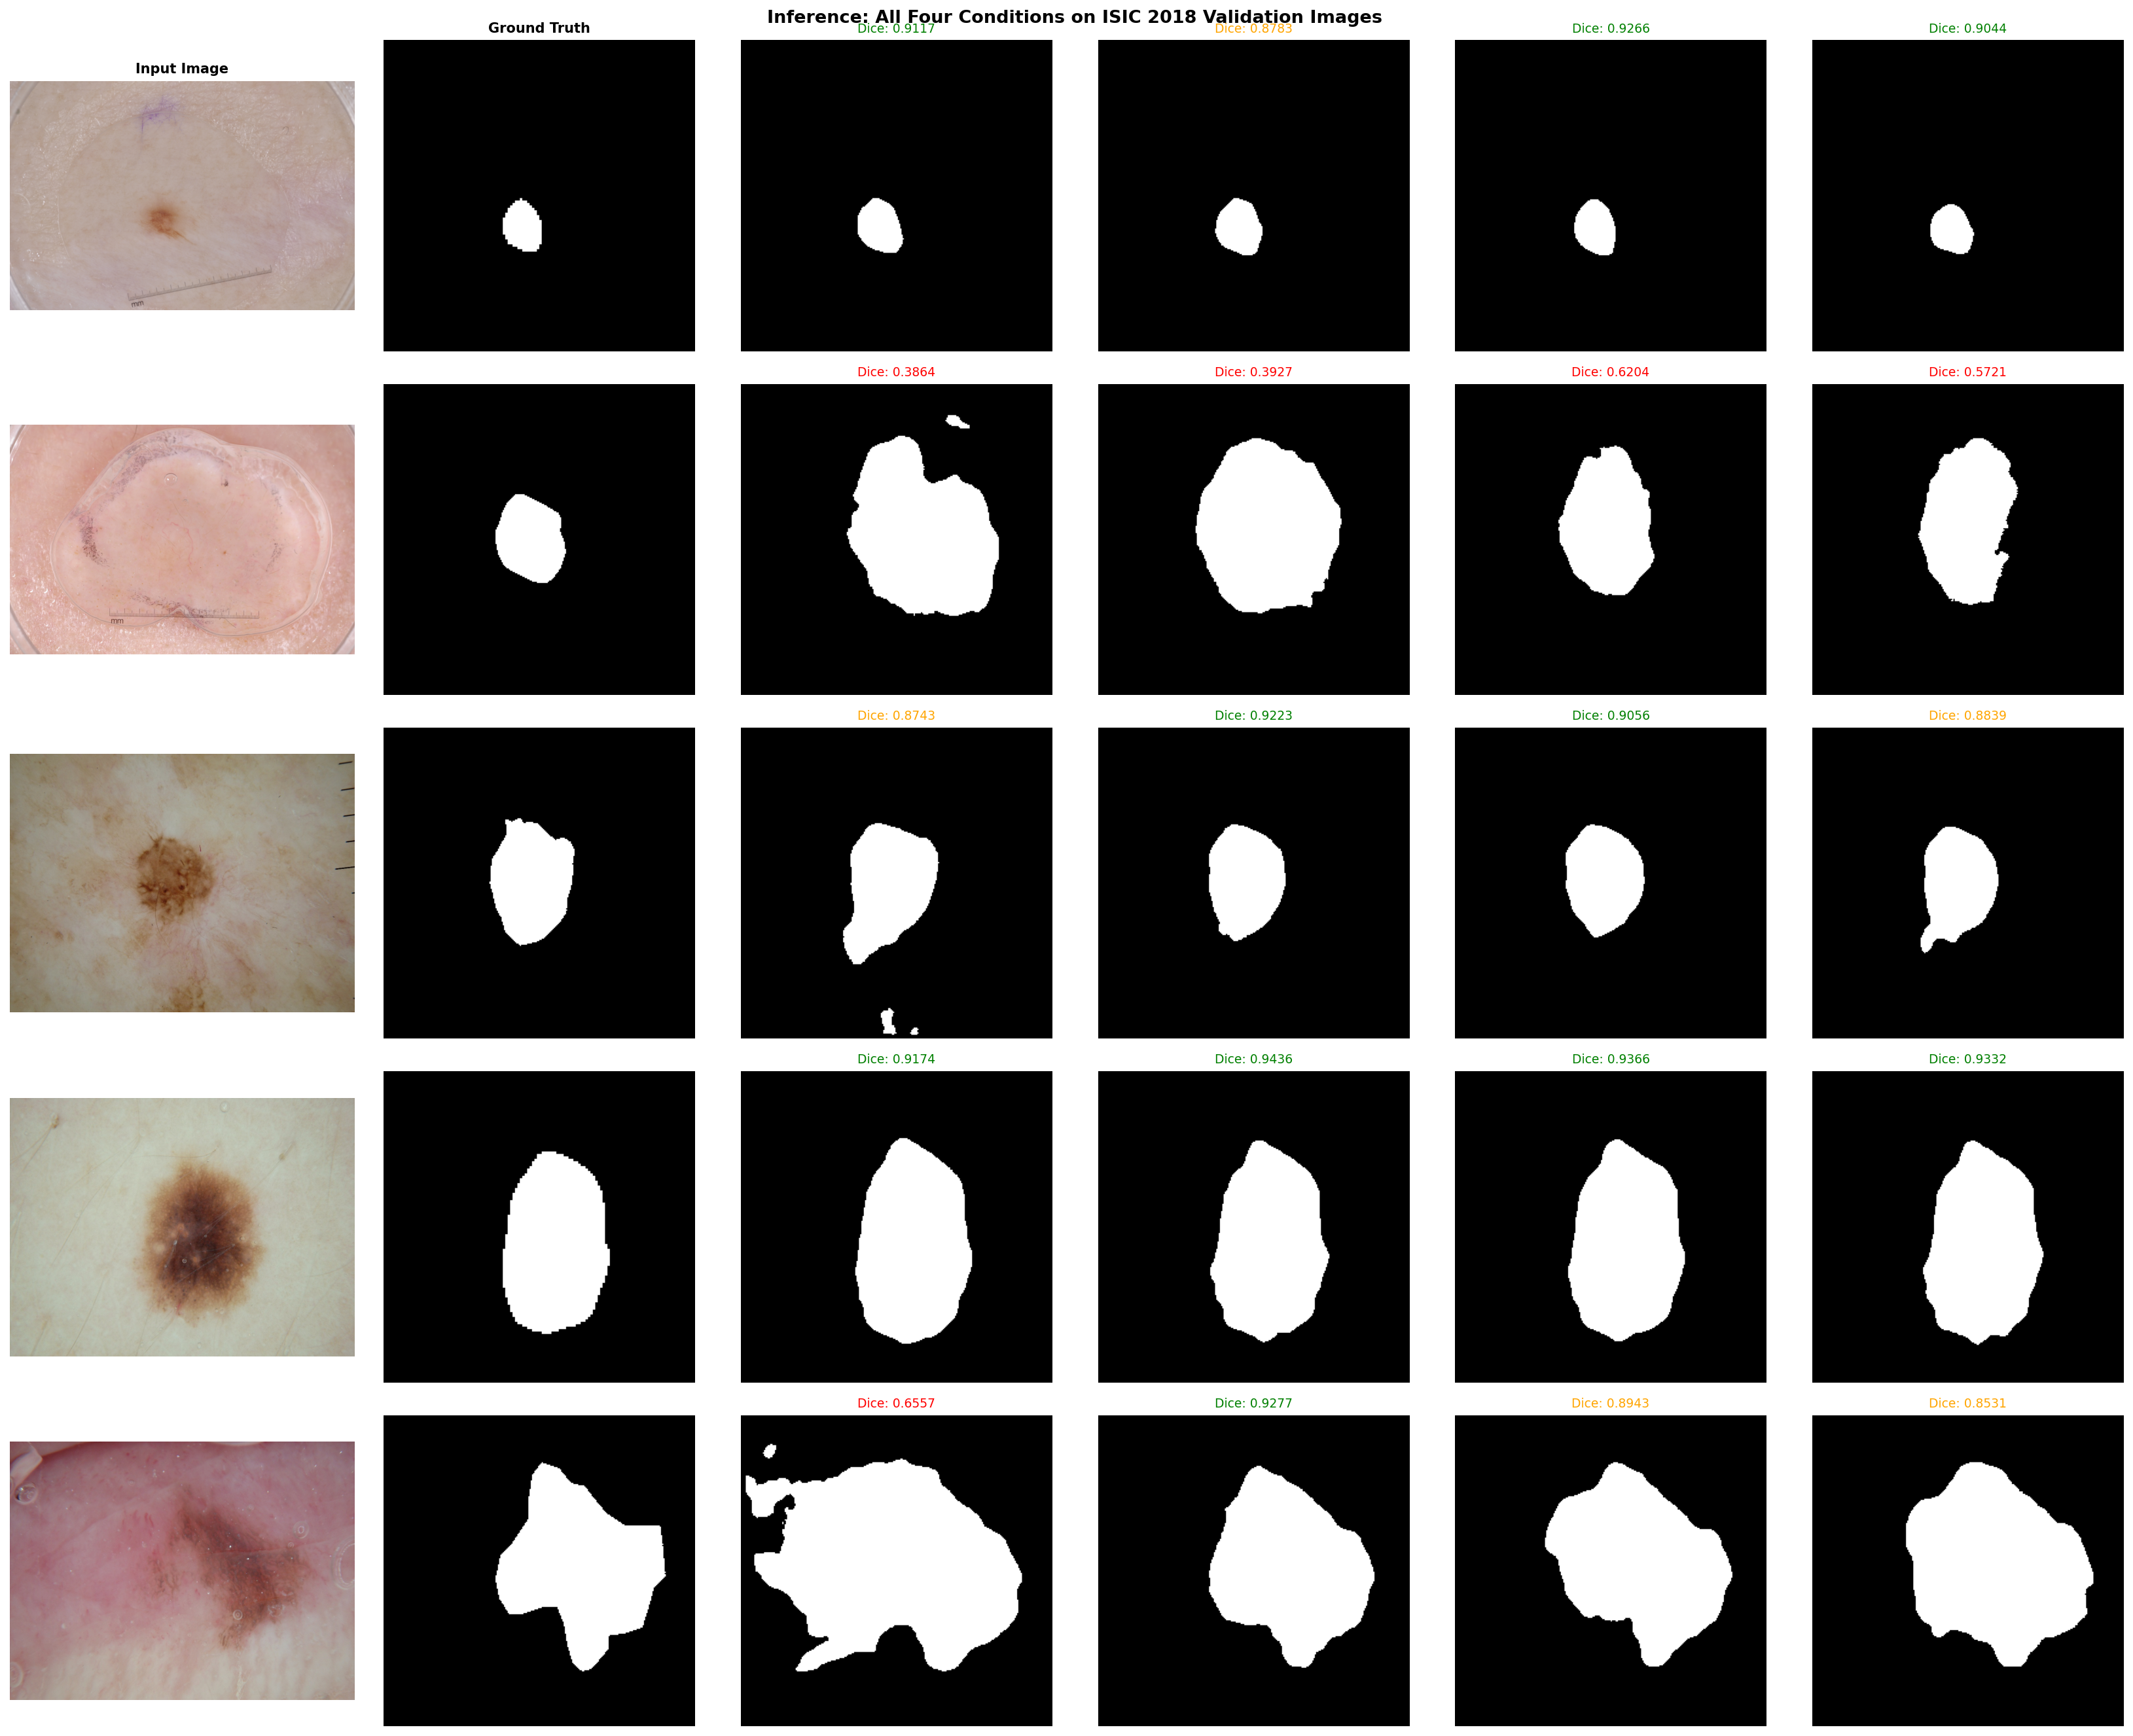

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os

val_img_dir  = '/content/ISIC2018/ISIC2018_Task1-2_Validation_Input'
val_mask_dir = '/content/ISIC2018/ISIC2018_Task1_Validation_GroundTruth'

transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_images = sorted([f for f in os.listdir(val_img_dir) if f.endswith('.jpg')])[:5]

fig, axes = plt.subplots(5, 6, figsize=(22, 18))
col_titles = ['Input Image', 'Ground Truth',
              'Cond A (Frozen)', 'Cond B (Fine-tuned)',
              'Cond C (Random)', 'Cond D (UNet++ scSE)']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

for row, img_name in enumerate(val_images):
    img = np.array(Image.open(os.path.join(val_img_dir, img_name)).convert('RGB'))
    mask_name = img_name.replace('.jpg', '_segmentation.png')
    gt_mask = np.array(Image.open(os.path.join(val_mask_dir, mask_name)).convert('L').resize((256, 256)))
    gt_binary = (gt_mask > 127).astype(np.uint8)

    aug = transform(image=img)
    tensor = aug['image'].unsqueeze(0).to(device)

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(gt_binary, cmap='gray')
    axes[row, 1].axis('off')

    for col, cond in enumerate(conditions):
        with torch.no_grad():
            pred = torch.sigmoid(models[cond](tensor))
        pred_mask = (pred.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

        intersection = (pred_mask * gt_binary).sum()
        dice = (2 * intersection + 1e-6) / (pred_mask.sum() + gt_binary.sum() + 1e-6)

        colour = 'green' if dice >= 0.90 else ('orange' if dice >= 0.80 else 'red')
        axes[row, col + 2].imshow(pred_mask, cmap='gray')
        axes[row, col + 2].set_title(f'Dice: {dice:.4f}', fontsize=9, color=colour)
        axes[row, col + 2].axis('off')

plt.suptitle('Inference: All Four Conditions on ISIC 2018 Validation Images',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/INM705/inference_notebook_output.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done! Output saved to Drive.')